# Notebook 4 — Unified reported-associations base

**What this establishes.** A single long-format table joining the 105 curated genotype→phenotype-
discordance loci (13 papers) against the frozen NHGRI-EBI GWAS Catalog pigmentation pull, by rsID —
**keeping both provenance rows** for anything reported in both places (no collapsing), plus a
gene-level GWAS-replication convergence annotation computed from the granular associations file.
This is the "does an independent GWAS signal exist for this gene" layer of the rescue-screen
convergence grade — one of several independent evidence lines, never a filter.

**Data pulled (named sources + counts):**
- `data/processed/discordance_loci_author_explained.csv` — 105 curated loci, 52 of them
  author-unexplained (`stated_unknown` + `nearest_gene_only`; NB3-upstream, not re-derived here).
- `data/external/gwas_catalog/pigmentation_gwas_catalog.csv` — 1,072 deduplicated lead GWAS Catalog
  associations (one row per rsID), frozen pull dated 2026-07-08T01:15:41Z.
- `data/external/gwas_catalog/gwas_pigmentation_associations.csv` — 723 granular associations
  (`gene`, `snp_id`, `pvalue`), used ONLY for the gene-level replication count.
- Kim et al. 2024 (PMID 38849341): **not folded in** — no extracted data file for this source exists
  anywhere in this repo (checked; see gap note in Step 7). Documented as a gap, not fabricated.

**What this contributes to the flagship.** One additive convergence signal
(`gwas_n_assoc` / `gwas_replicated`) attached at gene level to every locus in the unified base,
plus the cross-source rsID overlap between the 52 author-unexplained loci and the independently
curated GWAS Catalog — evidence that some author-unexplained loci already carry an independent
GWAS-level signal the original papers did not connect to a mechanism.

**The one number that matters:** of the **52 author-unexplained loci**, **27** share an rsID with
the 1,072-row GWAS Catalog pull, and **40** sit in a gene that clears the gene-level replication
threshold (`gwas_n_assoc >= 2` from the 723-row granular file, matched by gene *symbol* rather than
rsID — a distinct, gene-level convergence line, independent of the 52-set rsID overlap). The
unified base has **1,177 rows** (105 curated + 1,072 catalog, both provenances kept).

**Convergence annotation is additive, never a gate.** `gwas_replicated` (`gwas_n_assoc >= 2`) is
computed **only** from the granular 723-row file (not the deduplicated 1,072) and is attached to
every row as an extra column. It is explicitly **not** used to drop or filter anything downstream:
a `>=2` threshold is backwards for this project's thesis, because it systematically favors
canonical, heavily-studied nearest-genes (OCA2, HERC2, MC1R, IRF4 — the genes the field already
watches) and would discard exactly the off-canonical, singleton, or novel loci that are the rescue
targets. `gwas_replicated=False` on a locus is not evidence against it; it just means GWAS
replication is not (yet) one of its convergence lines.

**Matching discipline note.** Gene labels in both the curated set and the catalog are free text
with parenthetical annotations, positional qualifiers, and multi-gene lists (`HERC2 (near OCA2)`,
`OCA2/HERC2 intronic`, `ASIP/AHCY`). A naive exact-uppercase match against the granular file's
clean gene symbols only catches 63/105 curated rows; Step 4 builds a small symbol-extraction
helper (`extract_gene_symbols`) that recovers 87/105 — the gap is characterized explicitly in
Step 4 rather than silently accepted.

**Reproducibility.** All inputs are frozen, offline, and already committed in-repo (verified below,
Step 0). This notebook makes no live network calls; the regeneration script
(`scripts/pull_gwas_associations.py`) is documented but not run (the EBI download endpoint returns
HTTP 500 as of this writing).

> **Key terms — so this notebook stands on its own** (you shouldn't need the other notebooks to read this one).
>
> - **Author-unexplained locus** — a spot in the genome that a *published study reported as associated with pigmentation*, but whose original authors **could not say mechanistically why** it affects pigment, because it is **not in or near a canonical pigmentation gene**. The association is real; the responsible gene/mechanism is unknown. These come from the **13 hand-curated papers** assembled in NB3 — **not** from a GWAS database. Operationally they are the curated loci tagged `stated_unknown` or `nearest_gene_only`: **52 of the 105**.
> - **Canonical pigmentation gene** — a gene with a textbook, well-established role in making melanin (e.g. *TYR, OCA2, MC1R, SLC45A2, MITF*). A locus sitting *on* one of these is easy to explain; a locus *away* from all of them is what "author-unexplained" means.
> - **Curated / discordance loci (the 105)** — pigmentation-association loci read out of 13 papers by hand (in NB3), each tagged with whether that paper's authors explained its mechanism.
> - **The "rescue" screen** — this project's overall aim: take the author-unexplained loci and try to *rescue* them — connect each to the melanogenesis (pigment-making) network and grade it by how many independent lines of evidence agree. **This notebook builds just one of those evidence lines** (an independent GWAS signal).
> - **GWAS Catalog (used here)** — a *separate, independent* public database of gene–trait associations (NHGRI-EBI). It is used **only as a cross-check** — *does an independent GWAS signal also exist for this locus?* — and **never as the source of the loci, and never as a filter.**
> - **Convergence annotation, not a filter** — each evidence line is *added* as a column, never used to drop a locus. A locus with no GWAS signal is not rejected; it just has one fewer converging line.


## Step 0 — Setup and frozen-input verification

Resolve the repo root (works whether launched from `notebooks/` or the repo root, matching the
convention in Notebooks 2–3), then verify every frozen input this notebook reads is committed
in-repo under `data/` (never under the gitignored `/output/`).

In [1]:
import pandas as pd
import numpy as np
import re
import json
from pathlib import Path

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 200)

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROC = ROOT / "data" / "processed"
EXT_GWAS = ROOT / "data" / "external" / "gwas_catalog"

CURATED_CSV = PROC / "discordance_loci_author_explained.csv"
DEDUP_CSV = EXT_GWAS / "pigmentation_gwas_catalog.csv"
GRANULAR_CSV = EXT_GWAS / "gwas_pigmentation_associations.csv"
DEDUP_META = EXT_GWAS / "pigmentation_gwas_catalog.csv.meta.json"

for p in [CURATED_CSV, DEDUP_CSV, GRANULAR_CSV, DEDUP_META]:
    assert p.exists(), f"missing frozen input: {p}"
    assert "/output/" not in str(p), f"frozen input must NOT live under gitignored /output/: {p}"

print("ROOT resolved:", ROOT.name)
for p in [CURATED_CSV, DEDUP_CSV, GRANULAR_CSV, DEDUP_META]:
    print(f"  OK  {p.relative_to(ROOT)}")


ROOT resolved: pigmentation-gene-network
  OK  data/processed/discordance_loci_author_explained.csv
  OK  data/external/gwas_catalog/pigmentation_gwas_catalog.csv
  OK  data/external/gwas_catalog/gwas_pigmentation_associations.csv
  OK  data/external/gwas_catalog/pigmentation_gwas_catalog.csv.meta.json


### Re-runnable query cell (frozen-DB-notebook pattern) — NOT executed here

The GWAS Catalog pull is documented in `docs/specs/gwas_catalog.spec.md`: 10 EFO/OBA/MONDO trait
roots (`scripts/traits_pigmentation.json`), `includeChildTraits=true`, endpoint
`https://www.ebi.ac.uk/gwas/api/search/downloads`, access timestamp **2026-07-08T01:15:41Z** (the
version key — GWAS Catalog is a live resource with no release-numbered download endpoint). The
granular-associations file (`gwas_pigmentation_associations.csv`, 723 rows) was pulled via
`scripts/pull_gwas_associations.py` (EBI REST API, GRCh38, documented in that script's own
docstring) — it carries no committed `.meta.json`, which is itself a reproducibility gap this
notebook surfaces rather than papering over (Step 6).

As of this build, the EBI download endpoint used by `scripts/gwas_catalog.py` returns **HTTP 500**,
so re-pulling live is not possible from this sandbox regardless. The cell below shows the exact
regeneration command; `REQUERY` stays `False` — this notebook reads the frozen files loaded in
Step 0/1 only.

In [2]:
REQUERY = False   # flip to True and run OUTSIDE the sandbox (network required) to re-pull
if REQUERY:
    import subprocess
    # Deduplicated lead-SNP pull (1,072 rows) — 10 frozen trait roots, see docs/specs/gwas_catalog.spec.md.
    # NOTE: as of this build the EBI download endpoint used here returns HTTP 500.
    subprocess.run(["python", "scripts/gwas_catalog.py"], cwd=ROOT, check=True)
    # Granular per-association pull (723 rows) — GWAS Catalog associations endpoint, per
    # scripts/pull_gwas_associations.py's own docstring (--genes / --region / --trait), then a
    # trivial column subset to efo_id,trait,gene,snp_id,pvalue (see DATA_SOURCES.md entry 1 /
    # internal/CHANGELOG.md). Re-run when EBI recovers; exact CLI args used for the frozen pull
    # are not recorded in-repo (documented gap, Step 6).
    print("see scripts/pull_gwas_associations.py --help for query modes")
print("REQUERY:", REQUERY, "(frozen files loaded below are the reproducible input)")


REQUERY: False (frozen files loaded below are the reproducible input)


## Step 1 — Load the frozen inputs

Three tables, all offline/committed:
1. `discordance_loci_author_explained.csv` (105 rows) — curated, NB3-upstream. **Not re-derived here.**
2. `pigmentation_gwas_catalog.csv` (1,072 rows) — deduplicated lead GWAS Catalog associations,
   one row per rsID, **GRCh38** (`pos_hg38`).
3. `gwas_pigmentation_associations.csv` (723 rows) — granular associations (`gene`, `snp_id`,
   `pvalue`), used only for the gene-level replication count in Step 4.

In [3]:
curated = pd.read_csv(CURATED_CSV)
dedup = pd.read_csv(DEDUP_CSV, dtype={"pvalue": str})   # p-values kept as strings (underflow-safe)
gran = pd.read_csv(GRANULAR_CSV)
dedup_meta = json.load(open(DEDUP_META))

assert len(curated) == 105, f"expected 105 curated loci, got {len(curated)}"
assert len(dedup) == 1072, f"expected 1072 deduplicated GWAS Catalog rows, got {len(dedup)}"
assert len(gran) == 723, f"expected 723 granular GWAS Catalog associations, got {len(gran)}"
assert dedup["rsid"].duplicated().sum() == 0, "dedup catalog should be one row per rsID"

print("curated loci:", len(curated), "columns:", list(curated.columns))
print("dedup GWAS Catalog:", len(dedup), "| pull access-UTC:", dedup_meta["queried_utc"])
print("granular GWAS Catalog:", len(gran), "columns:", list(gran.columns))

status_counts = curated["author_explanation_status"].value_counts()
print()
print("author_explanation_status distribution (105 curated loci):")
print(status_counts)


curated loci: 105 columns: ['paper', 'locus_id', 'rsid', 'coord_build', 'nearest_gene_label', 'gene_assignment_basis', 'paper_verdict', 'is_asserted_pigmentation', 'pvalue', 'population', 'needs_review', 'evidence_quote', 'author_explanation_status', 'author_explanation_quote', 'author_explanation_section', 'source_location', 'extraction_method', 'extraction_status', 'gene_label_correction', 'notes']
dedup GWAS Catalog: 1072 | pull access-UTC: 2026-07-08T01:15:41Z
granular GWAS Catalog: 723 columns: ['efo_id', 'trait', 'gene', 'snp_id', 'pvalue']

author_explanation_status distribution (105 curated loci):
author_explanation_status
mechanism_proposed    50
nearest_gene_only     37
stated_unknown        15
ambiguous              3
Name: count, dtype: int64


## Step 2 — Build-tag every locus

`discordance_loci_author_explained.csv`'s `coord_build` column is free text (each paper reports
coordinates its own way — some say `GRCh37/hg19` outright, some give only a bare `chrN`, some give
none at all). Classify every row into a controlled `coord_build_tag`:

- **GRCh37** — text contains `GRCh37`/`hg19`/`b37`.
- **GRCh38** — text contains `GRCh38`/`hg38`/`b38`.
- **ambiguous** — a chromosome is named (`chrN`) but no build token is given anywhere in the row
  (could be either build; two such rows in this set — Crawford2017 `chr16` and Salvo2023 `chr15`,
  both position-not-stated).
- **no_build** — no chromosome and no build token at all (covariates, cDNA/codon numbering,
  supplementary-table-only rsIDs, etc.).

The GWAS Catalog rows are uniformly `GRCh38` (`pos_hg38`, as served by the download endpoint —
documented in `docs/specs/gwas_catalog.spec.md`).

In [4]:
def classify_build(coord_build_text):
    # Controlled coord_build_tag from the free-text coord_build column.
    if pd.isna(coord_build_text):
        return "no_build"
    s = str(coord_build_text).lower()
    has37 = bool(re.search(r"grch37|hg19|\bb37\b", s))
    has38 = bool(re.search(r"grch38|hg38|\bb38\b", s))
    if has37 and has38:
        return "ambiguous"
    if has37:
        return "GRCh37"
    if has38:
        return "GRCh38"
    if re.search(r"chr\d", s):
        return "ambiguous"   # a chromosome is named but no build token anywhere -> genuinely ambiguous
    return "no_build"

curated["coord_build_tag"] = curated["coord_build"].apply(classify_build)
build_counts = curated["coord_build_tag"].value_counts()
print(build_counts)

assert build_counts.get("GRCh37", 0) == 74, f"expected 74 GRCh37, got {build_counts.get('GRCh37', 0)}"
assert build_counts.get("no_build", 0) == 23, f"expected 23 no_build, got {build_counts.get('no_build', 0)}"
assert build_counts.get("GRCh38", 0) == 6, f"expected 6 GRCh38, got {build_counts.get('GRCh38', 0)}"
assert build_counts.get("ambiguous", 0) == 2, f"expected 2 ambiguous, got {build_counts.get('ambiguous', 0)}"
print()
print("ambiguous rows (chromosome named, no build token):")
print(curated.loc[curated["coord_build_tag"] == "ambiguous", ["paper", "locus_id", "coord_build"]].to_string(index=False))


coord_build_tag
GRCh37       74
no_build     23
GRCh38        6
ambiguous     2
Name: count, dtype: int64

ambiguous rows (chromosome named, no build token):
       paper                                                     locus_id                          coord_build
Crawford2017 MC1R (contrast reference; monomorphic/constrained in Africa) chr16 (position not stated in paper)
   Salvo2023                        OCA2 rs121918166 blue-eye (confirmed)                                chr15


## Step 3 — Extract rsIDs and join curated loci to the GWAS Catalog

`discordance_loci_author_explained.csv`'s `rsid` column is also free text: a clean rsID
(`rs12913832`), a primary rsID with parenthetical context (`rs35389 (representative of a 4-SNP
credible set...)`), or no rsID at all (covariates, a locus with no dbSNP entry at publication,
an unenumerated variant set). Extract every `rs\d+` token from both `rsid` and `locus_id` (some
rows name a second rsID only in `locus_id`) and use that set to join against the GWAS Catalog.

**Both provenance rows are kept — nothing is collapsed.** A curated locus that also appears in the
GWAS Catalog gets an `also_in_gwas_catalog_dedup` / `also_in_gwas_catalog_granular` cross-reference
flag on its own curated row; the matching catalog row(s) independently carry
`also_in_curated_105` / `also_in_curated_52_unexplained` flags on their own row. The unified base
built in Step 5 is the union of both row sets, not a merge that drops one side.

In [5]:
def extract_rsids(text):
    if pd.isna(text):
        return []
    return re.findall(r"rs\d+", str(text))

curated["rsid_all"] = curated.apply(lambda r: sorted(set(extract_rsids(r["rsid"]) + extract_rsids(r["locus_id"]))), axis=1)
curated["rsid_primary"] = curated["rsid_all"].apply(lambda l: l[0] if l else None)

n_no_rsid = (curated["rsid_all"].apply(len) == 0).sum()
print(f"curated loci with >=1 extractable rsID: {105 - n_no_rsid} of 105")
print(f"curated loci with NO extractable rsID (covariates / no dbSNP entry / unenumerated sets): {n_no_rsid}")

dedup_rsid_set = set(dedup["rsid"])
gran_rsid_set = set(gran["snp_id"])

def overlap(rsid_list, rsid_set):
    return [r for r in rsid_list if r in rsid_set]

curated["catalog_dedup_rsid_hits"] = curated["rsid_all"].apply(lambda l: overlap(l, dedup_rsid_set))
curated["catalog_granular_rsid_hits"] = curated["rsid_all"].apply(lambda l: overlap(l, gran_rsid_set))
curated["also_in_gwas_catalog_dedup"] = curated["catalog_dedup_rsid_hits"].apply(len) > 0
curated["also_in_gwas_catalog_granular"] = curated["catalog_granular_rsid_hits"].apply(len) > 0

print()
print("curated loci (105) also in dedup GWAS Catalog (1,072) by rsID:", curated["also_in_gwas_catalog_dedup"].sum())
print("curated loci (105) also in granular GWAS Catalog (723) by rsID:", curated["also_in_gwas_catalog_granular"].sum())


curated loci with >=1 extractable rsID: 93 of 105
curated loci with NO extractable rsID (covariates / no dbSNP entry / unenumerated sets): 12

curated loci (105) also in dedup GWAS Catalog (1,072) by rsID: 63
curated loci (105) also in granular GWAS Catalog (723) by rsID: 61


### The rsID overlap for the 52 author-unexplained loci (headline cross-source signal)

The 52-locus rescue-candidate set (`stated_unknown` + `nearest_gene_only`, from the upstream NB3
spec's rescue-candidate ledger) is the population this build's rescue-candidate analysis draws
from. How many of those 52 already have an independent rsID hit in the GWAS Catalog?

In [6]:
RESCUE_52_STATUSES = ["stated_unknown", "nearest_gene_only"]
rescue52_mask = curated["author_explanation_status"].isin(RESCUE_52_STATUSES)
n_rescue52 = int(rescue52_mask.sum())
assert n_rescue52 == 52, f"expected 52 author-unexplained loci, got {n_rescue52}"

rescue52 = curated.loc[rescue52_mask]
n_rescue52_with_rsid = int((rescue52["rsid_all"].apply(len) > 0).sum())
n_rescue52_in_dedup = int(rescue52["also_in_gwas_catalog_dedup"].sum())
n_rescue52_in_granular = int(rescue52["also_in_gwas_catalog_granular"].sum())

print(f"author-unexplained loci (52-set): {n_rescue52}")
print(f"  ...with >=1 extractable rsID:            {n_rescue52_with_rsid}")
print(f"  ...also in dedup GWAS Catalog (1,072):    {n_rescue52_in_dedup}")
print(f"  ...also in granular GWAS Catalog (723):   {n_rescue52_in_granular}")
print()
print("52-set loci with a GWAS Catalog rsID hit (dedup, 1,072):")
print(rescue52.loc[rescue52["also_in_gwas_catalog_dedup"], ["paper", "rsid_primary", "nearest_gene_label", "author_explanation_status"]].to_string(index=False))


author-unexplained loci (52-set): 52
  ...with >=1 extractable rsID:            49
  ...also in dedup GWAS Catalog (1,072):    27
  ...also in granular GWAS Catalog (723):   25

52-set loci with a GWAS Catalog rsID hit (dedup, 1,072):
             paper rsid_primary                                                     nearest_gene_label author_explanation_status
           Ang2023     rs676091                                                       KALRN (intronic)            stated_unknown
           Ang2023    rs6816819                                                LOC107986284 (intronic)            stated_unknown
           Ang2023    rs1540771                                                              near IRF4         nearest_gene_only
           Ang2023   rs10809826                                                       TYRP1 (upstream)         nearest_gene_only
           Ang2023    rs2153271                                                        BNC2 (intronic)         nearest_g

## Step 4 — Gene-level GWAS-replication convergence annotation (ADDITIVE, never a gate)

Computed from the **granular 723-row file only** (never the deduplicated 1,072 — the dedup table
is one row per rsID and cannot support a per-gene association count). Group by `gene`, count
associations, flag `gwas_replicated = (gwas_n_assoc >= 2)`.

**Matching discipline.** `gene` in the granular file is a single clean symbol, but the curated
set's `nearest_gene_label` and the catalog's `mapped_gene` are free text — parenthetical position
annotations (`HERC2 (near OCA2)`), positional qualifiers without parentheses (`OCA2/HERC2
intronic`), and multi-gene lists (`ASIP/AHCY`, `AMIGO1 - GPR61`) are common. A naive uppercase-only
match against `gene_conv` misses most of these (only 63/105 curated rows would match). A small
`extract_gene_symbols()` helper strips parenthetical text and trailing positional qualifiers
(`intronic`, `upstream`, `enhancer`, ...), splits multi-gene lists on `/`, `,`, `;`, or `-`, and
matches every extracted candidate symbol — a row is annotated from the best (highest-`gwas_n_assoc`)
matching symbol among its candidates.

**This is explicitly an additive convergence annotation, not a filter.** A `>=2`-association gate
would be backwards for this project's thesis: it systematically rewards the canonical,
heavily-GWAS'd nearest-genes (OCA2, MC1R, HERC2, IRF4 — genes the field already watches closely)
and would silently discard exactly the off-canonical, singleton, or novel loci that the rescue
screen exists to surface. `gwas_n_assoc` and `gwas_replicated` are attached as extra columns to
every row of the unified base (both curated and catalog provenance) and used downstream as ONE
of several independent evidence lines feeding the convergence grade — never to drop a candidate.

In [7]:
assert gran["gene"].isna().sum() == 0, "granular file should have 0 gene-less rows"

gene_conv = (
    gran.groupby("gene", as_index=False)
    .agg(gwas_n_assoc=("snp_id", "count"))
)
gene_conv["gwas_replicated"] = gene_conv["gwas_n_assoc"] >= 2
gene_conv["gene_label_norm"] = gene_conv["gene"].str.strip().str.upper()

n_genes = len(gene_conv)
n_replicated = int(gene_conv["gwas_replicated"].sum())
print(f"genes with >=1 granular association: {n_genes}")
print(f"genes with gwas_replicated=True (gwas_n_assoc >= 2): {n_replicated}")
assert n_replicated == 83, f"expected ~83 replicated genes, got {n_replicated}"

print()
print("top 10 genes by granular association count:")
print(gene_conv.sort_values("gwas_n_assoc", ascending=False).head(10)[["gene", "gwas_n_assoc", "gwas_replicated"]].to_string(index=False))

GENE_CONV_MAP = dict(zip(gene_conv["gene_label_norm"], zip(gene_conv["gwas_n_assoc"], gene_conv["gwas_replicated"])))

QUALIFIER_WORDS = {"INTRONIC", "UPSTREAM", "DOWNSTREAM", "INTRON", "EXON", "CODING", "NONCODING",
                    "NON-SYNONYMOUS", "MISSENSE", "REGION", "3'UTR", "5'UTR", "PROMOTER", "ENHANCER"}

def extract_gene_symbols(label):
    """Candidate gene symbol(s) from free-text gene label (curated nearest_gene_label or
    catalog mapped_gene): drop parenthetical annotation, split multi-gene lists on / , ; -,
    drop a leading near/in/within qualifier and a trailing positional qualifier word."""
    if pd.isna(label):
        return []
    s = re.sub(r"\(.*?\)", "", str(label))
    parts = re.split(r"\s*/\s*|\s*,\s*|\s*;\s*|\s+-\s+", s)
    out = []
    for p in parts:
        p = re.sub(r"^(near|in|within)\s+", "", p.strip(), flags=re.IGNORECASE)
        tokens = p.strip().split()
        while tokens and tokens[-1].upper().strip(",.'").replace("'", "") in {w.replace("'", "") for w in QUALIFIER_WORDS}:
            tokens = tokens[:-1]
        p2 = " ".join(tokens).strip().upper()
        if p2 and p2 not in ("SEX", "NAM ANCESTRY FRACTION", "NOT A GENE", ""):
            out.append(p2)
    return out

def annotate_convergence(label):
    """Best (highest-gwas_n_assoc) match among all candidate symbols extracted from label."""
    matches = [(s, GENE_CONV_MAP[s]) for s in extract_gene_symbols(label) if s in GENE_CONV_MAP]
    if not matches:
        return 0, False
    n = max(m[1][0] for m in matches)
    rep = any(m[1][1] for m in matches)
    return n, rep

n_matched_naive = int((curated["nearest_gene_label"].str.strip().str.upper().isin(GENE_CONV_MAP)).sum())
print()
print(f"curated rows matched by naive exact-uppercase label (no cleanup): {n_matched_naive} of 105")


genes with >=1 granular association: 318
genes with gwas_replicated=True (gwas_n_assoc >= 2): 83

top 10 genes by granular association count:
   gene  gwas_n_assoc  gwas_replicated
   OCA2            58             True
   MC1R            48             True
  HERC2            40             True
   IRF4            36             True
SLC45A2            23             True
    TYR            17             True
SLC24A4            17             True
SLC24A5            14             True
  KITLG            12             True
  TYRP1            11             True

curated rows matched by naive exact-uppercase label (no cleanup): 63 of 105


## Step 5 — Assemble the unified long-format base

One long table with **1,177 rows = 105 curated + 1,072 GWAS Catalog** — both provenance rows kept
for every locus reported in both sources, distinguished by `source_type`. Every row carries:
- `locus_key` (primary rsID, or a `paper::locus_id` composite when no rsID exists)
- the build tag from Step 2 (curated rows) or `GRCh38` (catalog rows, as served)
- the `also_in_*` cross-reference flags from Step 3
- the additive `gwas_n_assoc` / `gwas_replicated` gene-level annotation from Step 4, applied via
  `annotate_convergence()` (multi-symbol-aware, not a naive exact-string merge) to both the
  curated `nearest_gene_label` and the catalog `mapped_gene` columns.

In [8]:
def norm_gene(g):
    return None if pd.isna(g) else str(g).strip().upper()

# ---- curated provenance rows (105) ----
curated_long = curated.copy()
curated_long["source_type"] = "curated_paper"
curated_long["locus_key"] = curated_long["rsid_primary"].fillna(
    curated_long["paper"] + "::" + curated_long["locus_id"].str.slice(0, 40)
)
curated_long["gene_label"] = curated_long["nearest_gene_label"]
curated_long["gene_label_norm"] = curated_long["gene_label"].apply(norm_gene)
curated_long["ancestry"] = curated_long["population"]
curated_long["also_in_curated_105"] = True
curated_long["also_in_curated_52_unexplained"] = curated_long["author_explanation_status"].isin(RESCUE_52_STATUSES)
curated_long["catalog_dedup_rsid_hits"] = curated_long["catalog_dedup_rsid_hits"].apply(lambda l: ";".join(l) if l else None)
curated_long["gwas_n_assoc"], curated_long["gwas_replicated"] = zip(*curated_long["gene_label"].apply(annotate_convergence))
for c in ["pubmed", "study_accession", "chr", "pos_hg38", "queried_utc"]:
    curated_long[c] = None

# ---- GWAS Catalog provenance rows (1,072) ----
curated_rsid_universe = set(r for l in curated["rsid_all"] for r in l)
rescue52_rsid_universe = set(r for l in rescue52["rsid_all"] for r in l)

dedup_long = dedup.copy()
dedup_long["source_type"] = "gwas_catalog_dedup"
dedup_long["locus_key"] = dedup_long["rsid"]
dedup_long["rsid_primary"] = dedup_long["rsid"]
dedup_long["gene_label"] = dedup_long["mapped_gene"]
dedup_long["gene_label_norm"] = dedup_long["gene_label"].apply(norm_gene)
dedup_long["coord_build"] = "GRCh38 (pos_hg38, as served by GWAS Catalog download endpoint)"
dedup_long["coord_build_tag"] = "GRCh38"
dedup_long["also_in_curated_105"] = dedup_long["rsid"].isin(curated_rsid_universe)
dedup_long["also_in_curated_52_unexplained"] = dedup_long["rsid"].isin(rescue52_rsid_universe)
dedup_long["also_in_gwas_catalog_dedup"] = True
dedup_long["also_in_gwas_catalog_granular"] = dedup_long["rsid"].isin(gran_rsid_set)
dedup_long["population"] = dedup_long["ancestry"]
dedup_long["source_location"] = dedup_long["study_accession"]
dedup_long["gwas_n_assoc"], dedup_long["gwas_replicated"] = zip(*dedup_long["gene_label"].apply(annotate_convergence))
for c in ["paper", "locus_id", "gene_assignment_basis", "paper_verdict", "is_asserted_pigmentation",
          "author_explanation_status", "author_explanation_quote", "catalog_dedup_rsid_hits"]:
    dedup_long[c] = None

SHARED_COLS = [
    "locus_key", "source_type", "paper", "locus_id", "rsid", "rsid_primary", "coord_build", "coord_build_tag",
    "gene_label", "gene_label_norm", "gene_assignment_basis", "paper_verdict", "is_asserted_pigmentation",
    "pvalue", "population", "ancestry", "author_explanation_status", "author_explanation_quote",
    "source_location", "pubmed", "study_accession", "chr", "pos_hg38", "queried_utc",
    "also_in_curated_105", "also_in_curated_52_unexplained", "also_in_gwas_catalog_dedup",
    "also_in_gwas_catalog_granular", "catalog_dedup_rsid_hits", "gwas_n_assoc", "gwas_replicated",
]

unified = pd.concat([curated_long[SHARED_COLS], dedup_long[SHARED_COLS]], ignore_index=True)
unified["gwas_n_assoc"] = unified["gwas_n_assoc"].fillna(0).astype(int)
unified["gwas_replicated"] = unified["gwas_replicated"].fillna(False).astype(bool)

print("unified base rows:", len(unified))
assert len(unified) == 1177, f"expected 1177 unified rows, got {len(unified)}"
print(unified["source_type"].value_counts())
print()
n_curated_replicated = int(curated_long["gwas_replicated"].sum())
print(f"curated rows (105) with gwas_replicated=True (multi-symbol-aware match): {n_curated_replicated}")


unified base rows: 1177
source_type
gwas_catalog_dedup    1072
curated_paper          105
Name: count, dtype: int64

curated rows (105) with gwas_replicated=True (multi-symbol-aware match): 87


## Step 6 — Figure: the 105 → 52 funnel, with GWAS Catalog overlap

Rough, functional figure only: 105 curated loci → 52 author-unexplained (`stated_unknown` +
`nearest_gene_only`) → of those 52, 27 also carry an rsID hit in the 1,072-row GWAS Catalog pull.

saved figures/nb4_funnel.png


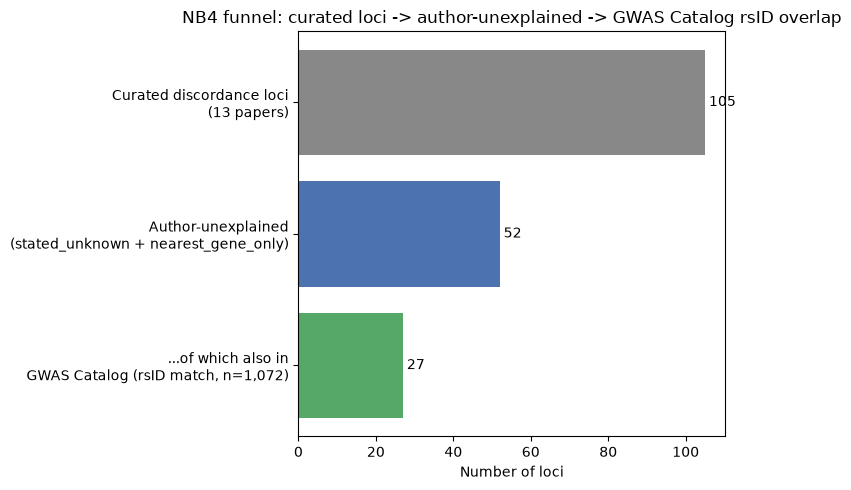

In [9]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

n_curated = len(curated)
n_rescue52_final = n_rescue52
n_rescue52_gwas_overlap = n_rescue52_in_dedup

stages = [
    ("Curated discordance loci\n(13 papers)", n_curated),
    ("Author-unexplained\n(stated_unknown + nearest_gene_only)", n_rescue52_final),
    ("...of which also in\nGWAS Catalog (rsID match, n=1,072)", n_rescue52_gwas_overlap),
]
labels = [s[0] for s in stages]
vals = [s[1] for s in stages]

fig, ax = plt.subplots(figsize=(7.5, 5))
ax.barh(range(len(stages)), vals, color=["#888888", "#4C72B0", "#55A868"])
ax.set_yticks(range(len(stages)))
ax.set_yticklabels(labels)
ax.invert_yaxis()
ax.set_xlabel("Number of loci")
ax.set_title("NB4 funnel: curated loci -> author-unexplained -> GWAS Catalog rsID overlap")
for i, v in enumerate(vals):
    ax.text(v + 1, i, str(v), va="center")
fig.tight_layout()
fig.savefig("figures/nb4_funnel.png", dpi=120)
plt.show()
print("saved figures/nb4_funnel.png")


## Step 7 — Kim et al. 2024 (PMID 38849341): documented gap, not folded in

The task brief for this notebook asked to fold in Kim 2024 (PMID 38849341, a 48,433-person East
Asian population skin-colour atlas) as an additional curated source row **if extractable from the
repo**. A repo-wide search confirms it is referenced only as a citation in internal planning docs
(`internal/START_HERE.md`, `internal/PROJECT_EVOLUTION.md`, `internal/CHANGELOG.md`) — there is
**no extracted association table, no raw file, and no `data/processed/` output** for this source
anywhere in the repository. `internal/CHANGELOG.md` records that a standalone population atlas
built from Kim 2024 was deliberately **preempted** (the source's own atlas already exists; this
project cites it rather than re-deriving it).

**This is surfaced here as a gap, not fabricated.** No Kim 2024 row is added to the unified base.
If a downstream step needs Kim 2024 associations, that extraction has to be opened as its own
sourcing task (a genetics-paper-extraction pass over the primary paper), not assumed present.

In [10]:
import subprocess
r = subprocess.run(["grep", "-ril", "38849341", "data/"], cwd=ROOT, capture_output=True, text=True)
print("files under data/ mentioning PMID 38849341 (Kim 2024):", repr(r.stdout.strip()) or "(none)")
r2 = subprocess.run(["grep", "-ril", "kim2024", "data/"], cwd=ROOT, capture_output=True, text=True)
print("files under data/ matching 'kim2024':", repr(r2.stdout.strip()) or "(none)")
print()
print("Conclusion: Kim 2024 is a documented gap for this build. No row added to the unified base.")


files under data/ mentioning PMID 38849341 (Kim 2024): ''
files under data/ matching 'kim2024': ''

Conclusion: Kim 2024 is a documented gap for this build. No row added to the unified base.


## Step 8 — Write the unified base and verify it reproduces from the frozen inputs

Write `data/processed/nb4_unified_association_base.csv`, then reload it and assert the reload
reproduces exactly what was just built in-memory — the standard frozen-DB-notebook closing check.

In [11]:
OUT_CSV = PROC / "nb4_unified_association_base.csv"
COL_ORDER = [
    "locus_key", "source_type", "also_in_curated_105", "also_in_curated_52_unexplained",
    "also_in_gwas_catalog_dedup", "also_in_gwas_catalog_granular",
    "paper", "locus_id", "rsid", "rsid_primary", "chr", "pos_hg38", "coord_build", "coord_build_tag",
    "gene_label", "gene_label_norm", "gene_assignment_basis", "paper_verdict", "is_asserted_pigmentation",
    "author_explanation_status", "author_explanation_quote", "pvalue", "population", "ancestry",
    "source_location", "pubmed", "study_accession", "queried_utc",
    "catalog_dedup_rsid_hits", "gwas_n_assoc", "gwas_replicated",
]
unified_out = unified[COL_ORDER].copy()
unified_out.to_csv(OUT_CSV, index=False)
print("wrote", OUT_CSV.relative_to(ROOT), unified_out.shape)

reloaded = pd.read_csv(OUT_CSV, dtype={"pvalue": str})
assert len(reloaded) == len(unified_out), "reload row count mismatch"
assert list(reloaded.columns) == COL_ORDER, "reload column mismatch"
reload_counts = reloaded["source_type"].value_counts().to_dict()
written_counts = unified_out["source_type"].value_counts().to_dict()
assert reload_counts == written_counts, "reload source_type distribution mismatch"
print("closing check passed: reload reproduces the written table exactly (rows, columns, source_type mix).")


wrote data/processed/nb4_unified_association_base.csv (1177, 31)
closing check passed: reload reproduces the written table exactly (rows, columns, source_type mix).


## Summary — the numbers this notebook contributes to the flagship

| Metric | Value |
|---|---|
| Unified base rows (curated + GWAS Catalog, both provenances kept) | **1,177** (105 + 1,072) |
| Curated loci confirmed (upstream, not re-derived) | 105 |
| Author-unexplained loci (rescue-candidate population) | **52** |
| 52-set loci with an independent GWAS Catalog rsID hit (1,072-row dedup) | **27** |
| Genes with >=1 granular GWAS association (723-row file) | 318 |
| Genes clearing the gene-level `gwas_replicated` (`>=2` assoc.) convergence annotation | **83** |
| 52-set loci whose gene clears `gwas_replicated` (symbol-matched, Step 4) | **40** |
| 105-set loci whose gene clears `gwas_replicated` (symbol-matched, Step 4) | 87 |
| coord_build tags (105 curated loci) | GRCh37 74 / no_build 23 / GRCh38 6 / ambiguous 2 |
| Kim et al. 2024 (PMID 38849341) | documented gap — no extracted table in-repo, not folded in |

`gwas_replicated` is an **additive convergence annotation**, computed only from the granular
723-row file, attached to every row of the unified base — it is never used to filter or gate a
candidate out of the rescue screen. Two independent convergence signals now exist for the
52-locus rescue population: the **rsID overlap** (27/52, an exact-variant cross-source hit) and
the **gene-level replication** (40/52, a broader same-gene signal that does not require the exact
variant to have been re-observed).